In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from lib import *

In [2]:
data = load_data("./traces.csv")
ranges = [("20km", 20_000), ("40km", 40_000), ("60km", 60_000)]

satellites = {key: struct_data(data, static_range=range_as_meters) for key, range_as_meters in ranges}

Chargement des satellites imposant une portée statique uniforme de 20000m (20.0km)
100 satellites ont été chargés
Temps écoulé : 51.31 secondes

Chargement des satellites imposant une portée statique uniforme de 40000m (40.0km)
100 satellites ont été chargés
Temps écoulé : 66.50 secondes

Chargement des satellites imposant une portée statique uniforme de 60000m (60.0km)
100 satellites ont été chargés
Temps écoulé : 88.49 secondes



In [3]:
each_range_each_instant = partial(run_for_each_range_each_instant, data, satellites)
each_range_each_instant_on_data = partial(run_for_each_range_each_instant_on_calculated_data, data, satellites)

In [4]:
print("Chargement des nombres de satellites inatteignables par instant")
nb_unreachable_satellites_by_instant = each_range_each_instant(func=count_unreachable_satellites)
print("Chargement des densités des graphes par instant")
degree_distribution_by_instant = each_range_each_instant(func=degree_distribution)
print("Chargement des densités des graphes par instant")
densities_by_instant = each_range_each_instant(func=density)
print("Chargement des valeurs de Fielder par instant")
fielder_value_by_instant = each_range_each_instant(func=fielder_value)
print("Chargement des sous-graphes par instant")
subgraphs_by_instant = each_range_each_instant(func=isolate_subgraphs)
print("Chargement des nombres de sous-graphes par instant")
nb_subgraphs_by_instant = each_range_each_instant_on_data(func=count_isolated_subgraphs, calculated_data=subgraphs_by_instant)
print("Chargement du nombre de 'clusters' par instant (sous-graphes avec noeud > 1)")
nb_isolated_clusters = each_range_each_instant_on_data(func=count_isolated_clusters, calculated_data=subgraphs_by_instant)

Chargement des nombres de satellites inatteignables par instant
Temps écoulé : 0.56 secondes

Chargement des densités des graphes par instant
Temps écoulé : 0.95 secondes

Chargement des densités des graphes par instant
Temps écoulé : 6.32 secondes

Chargement des valeurs de Fielder par instant
Temps écoulé : 36.27 secondes

Chargement des sous-graphes par instant
Temps écoulé : 2.13 secondes

Chargement des nombres de sous-graphes par instant
Temps écoulé : 0.01 secondes

Chargement du nombre de 'clusters' par instant (sous-graphes avec noeud > 1)
Temps écoulé : 0.12 secondes



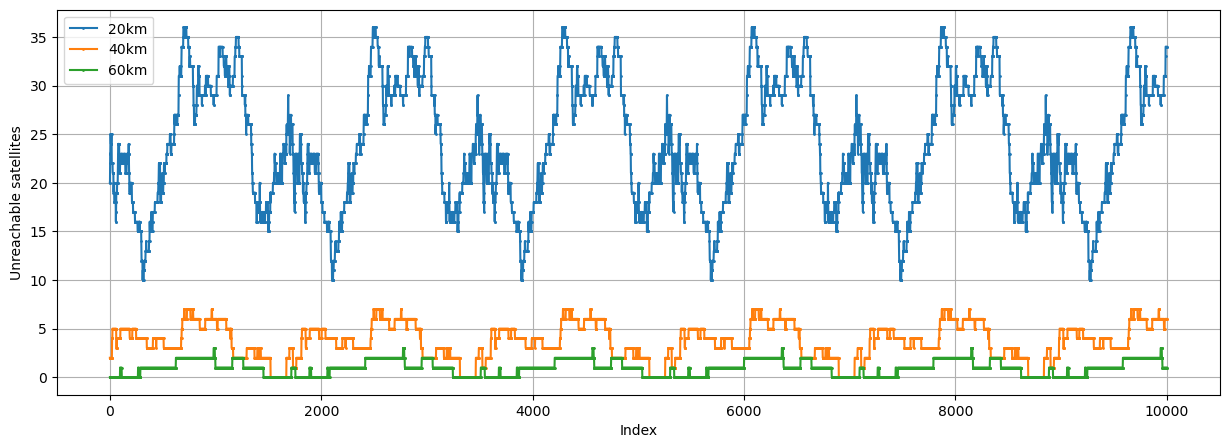

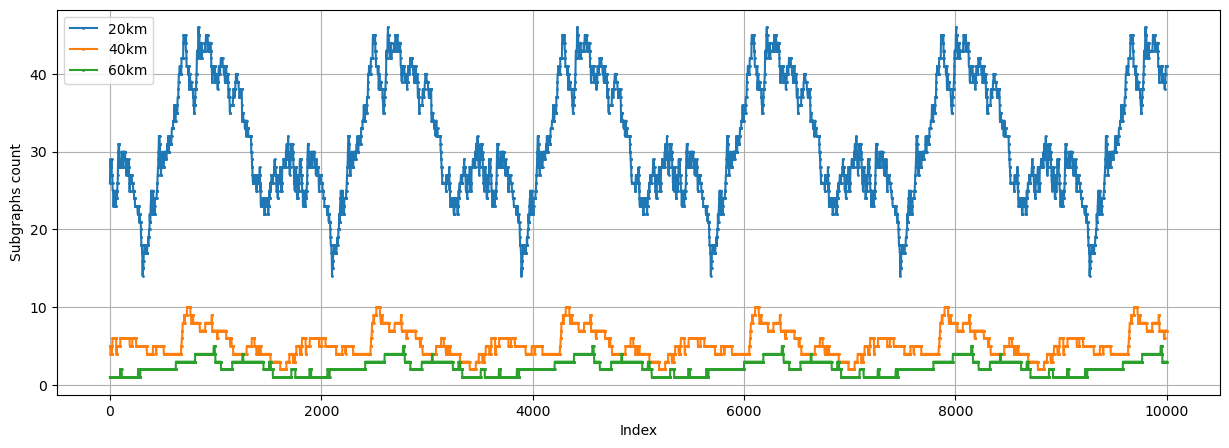

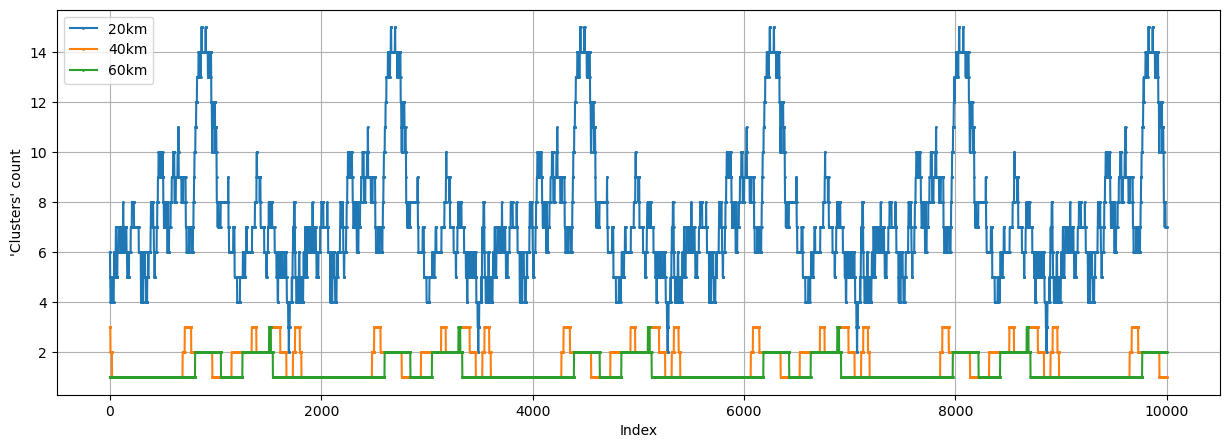

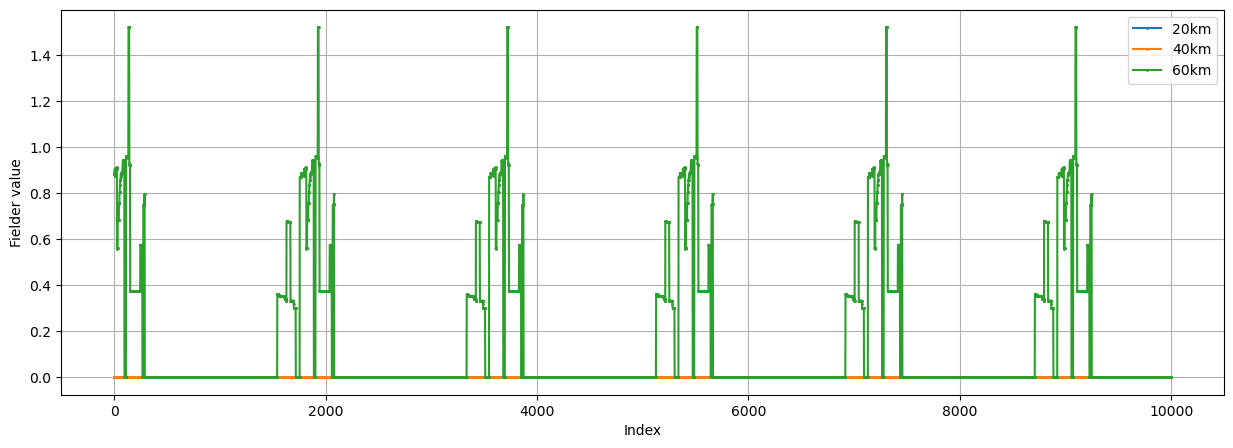

In [5]:
plots = [(nb_unreachable_satellites_by_instant, "Unreachable satellites"),
 (nb_subgraphs_by_instant, "Subgraphs count"),
 (nb_isolated_clusters, "'Clusters' count"),
 (fielder_value_by_instant, "Fielder value"),]

def show_data(data, y_title, title=None):
    df = pd.DataFrame(data)
    df.plot(marker='o', markersize=1, figsize=(15, 5))
    
    plt.xlabel("Index")
    plt.ylabel(y_title)
    plt.title(title)
    plt.grid(True)
    plt.show()

for data, y_title in plots:
    show_data(data, y_title)

In [6]:
start = time.perf_counter()
res = {key: dijkstra(satellites[key], 0, 0) for key in satellites.keys()}
end = time.perf_counter()
print(f"Temps écoulé : {end - start :.2f} secondes\n")

Temps écoulé : 0.08 secondes



In [7]:
instant_de_test = 0
sats_de_test = [sat.id for idx, sat in enumerate(satellites["20km"]) if idx % 5 == 0]

undo_failure(satellites["20km"], sats_de_test, [instant_de_test])

print(f"{count_unreachable_satellites(satellites["20km"], instant_de_test)} satellites injoignables avant panne franche programmée")

simulate_failure(satellites["20km"], sats_de_test, [instant_de_test])

print(f"{count_unreachable_satellites(satellites["20km"], instant_de_test)} satellites injoignables après panne franche programmée")

undo_failure(satellites["20km"], sats_de_test, [instant_de_test])

print(f"{count_unreachable_satellites(satellites["20km"], instant_de_test)} satellites injoignables avant panne franche programmée")

20 satellites injoignables avant panne franche programmée
44 satellites injoignables après panne franche programmée
20 satellites injoignables avant panne franche programmée


## Etude des instants critiques des révolutions

Nous nous intéresserons dans cette partie à la détection des instants les plus critiques des révolutions.

Dans ce but, nous nous baserons sur plusieurs caractéristiques :
- Une segmentation du graphe importante
- La valeur de Fielder nulle du graphe
- Détection du cluster principal et calcul de la valeur de fielder la plus dégradée

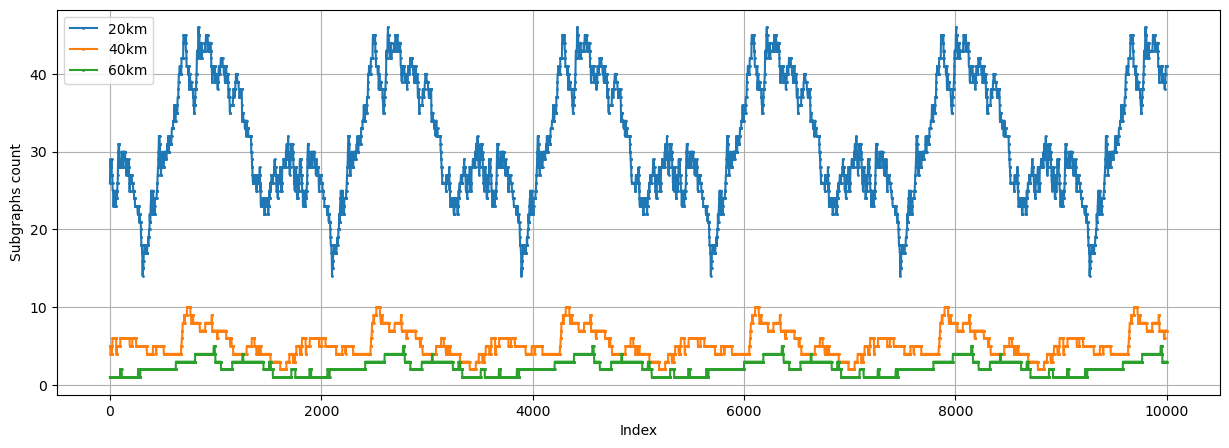

In [8]:
show_data(nb_subgraphs_by_instant, "Subgraphs count")

In [9]:
biggest_isolated_cluster_by_instant = each_range_each_instant_on_data(func=extract_biggest_cluster_from_subgraphs, calculated_data=subgraphs_by_instant)

Temps écoulé : 0.01 secondes



In [10]:
biggest_cluster_fielder_value_by_instant = {key: [fielder_value(biggest_isolated_cluster_by_instant[key][i], i) for i in range(len(satellites["20km"][1].list_coordinates))] for key in biggest_isolated_cluster_by_instant.keys()}

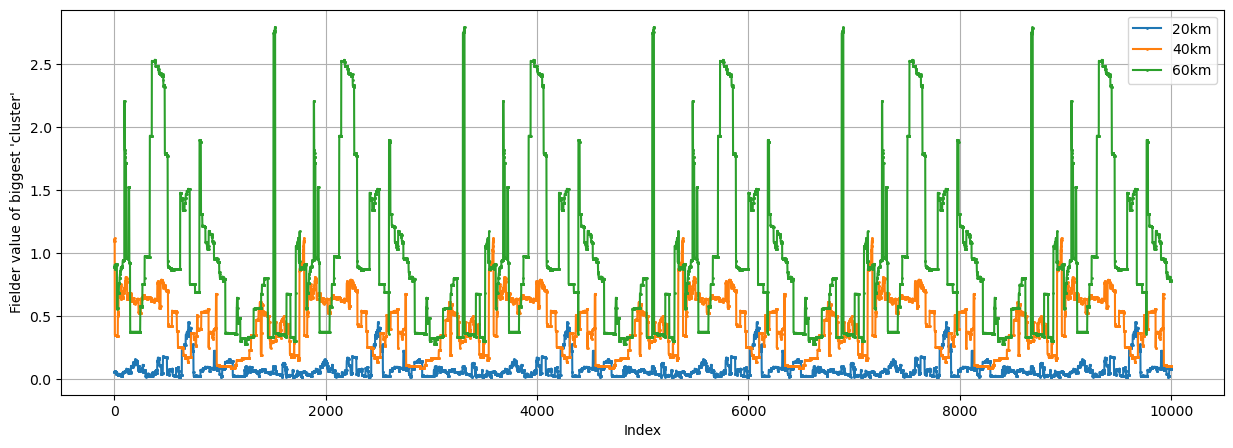

In [11]:
show_data(biggest_cluster_fielder_value_by_instant, "Fielder value of biggest 'cluster'")

In [12]:
from scipy.signal import find_peaks
import numpy as np

def detect_revolution(fielder_values: list[int]):
    arr = np.array(fielder_values)
    
    # Set a minimum distance between peaks to ~10% of signal length
    # This prevents finding noise peaks too close together
    min_distance = len(arr) // 10  # rough lower bound; tune if needed
    
    # prominence filters out shallow noise peaks — only tall, distinct peaks survive
    peaks, properties = find_peaks(
        arr,
        distance=min_distance,       # peaks must be at least this far apart
        prominence=np.std(arr) * 0.5 # peak must rise significantly above surroundings
    )
    
    if len(peaks) < 2:
        return None  # Not enough peaks found
    
    diffs = np.diff(peaks)
    period = np.median(diffs)
    return period

revolution = int(np.median([detect_revolution(biggest_cluster_fielder_value_by_instant[key]) for key in biggest_isolated_cluster_by_instant.keys()]))
revolution

1792

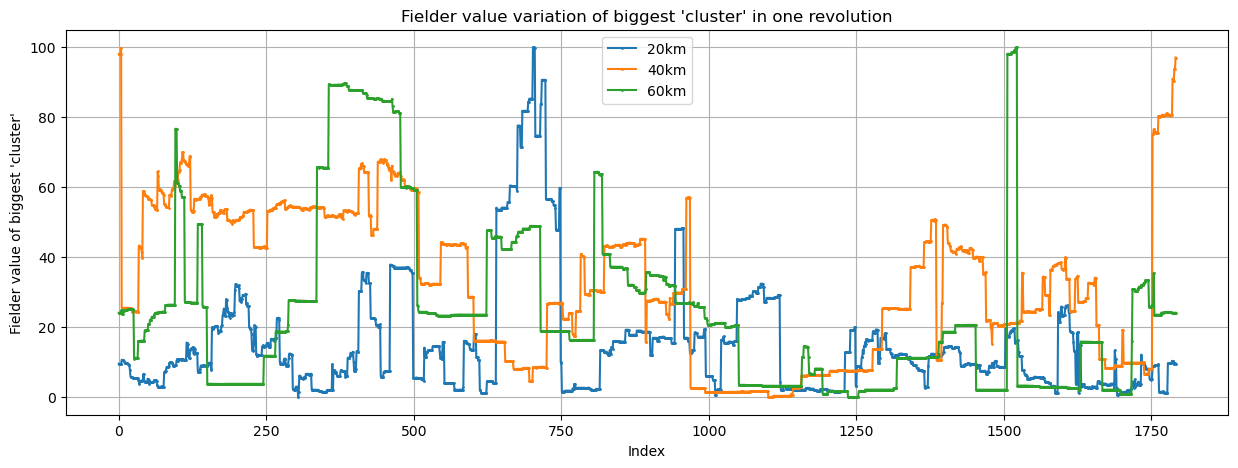

In [13]:
def fielder_value_to_variations(fielder_values: list[int], i: int, v_max, v_min):
    return (fielder_values[i] - v_min) / (v_max - v_min) * 100
v_maxs = {key: np.max(np.array(biggest_cluster_fielder_value_by_instant[key])) for key in biggest_isolated_cluster_by_instant.keys()}
v_mins = {key: np.min(np.array(biggest_cluster_fielder_value_by_instant[key])) for key in biggest_isolated_cluster_by_instant.keys()}
variations_fielder = {key: [fielder_value_to_variations(biggest_cluster_fielder_value_by_instant[key], i, v_maxs[key], v_mins[key]) for i in range(revolution)] for key in biggest_isolated_cluster_by_instant.keys()}
show_data(variations_fielder, "Fielder value of biggest 'cluster'", "Fielder value variation of biggest 'cluster' in one revolution")

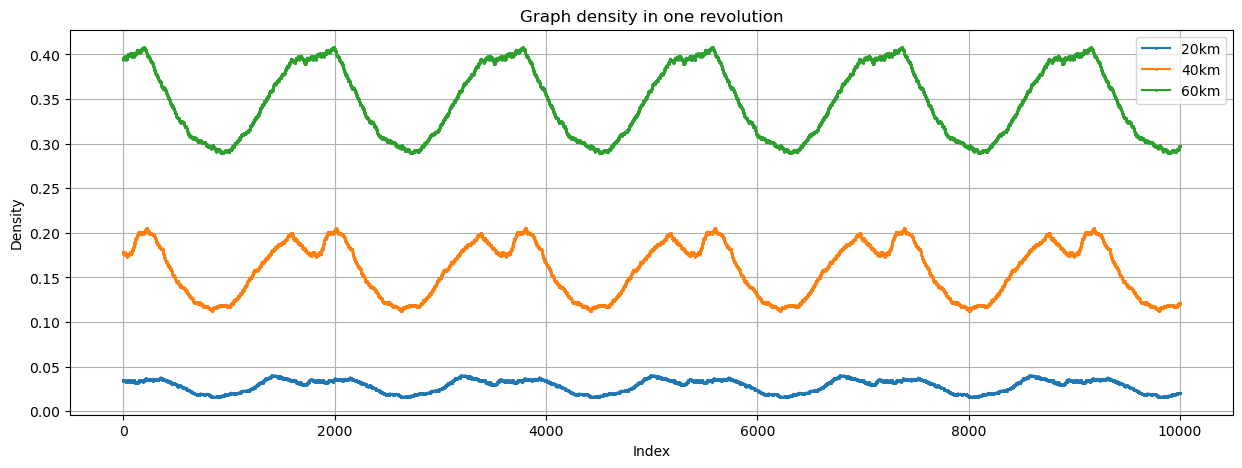

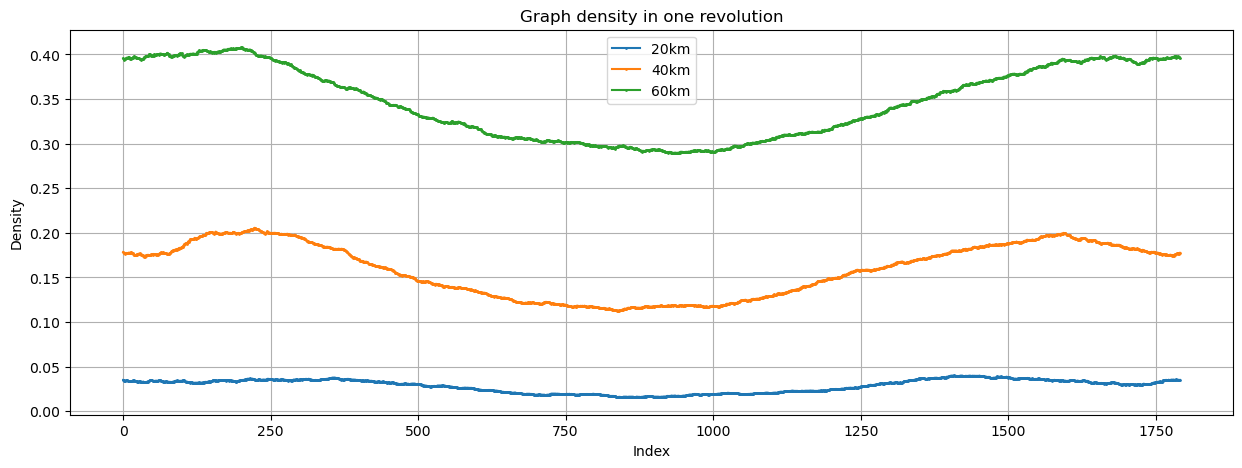

In [14]:
show_data(densities_by_instant, "Density", "Graph density in one revolution")
show_data({key: d_instants[:revolution] for key, d_instants in densities_by_instant.items()}, "Density", "Graph density in one revolution")

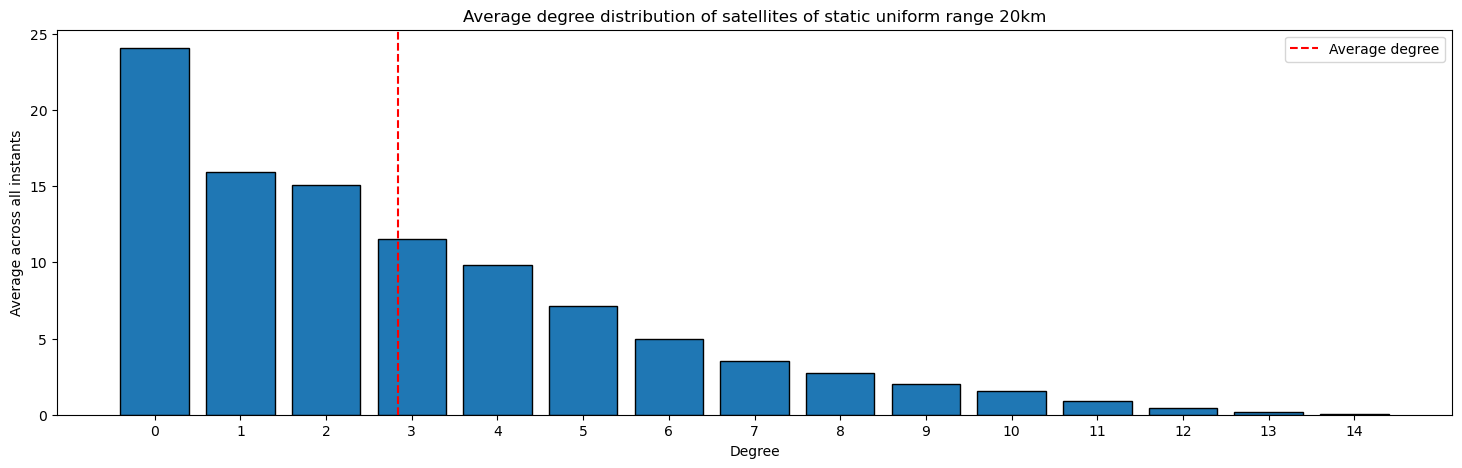

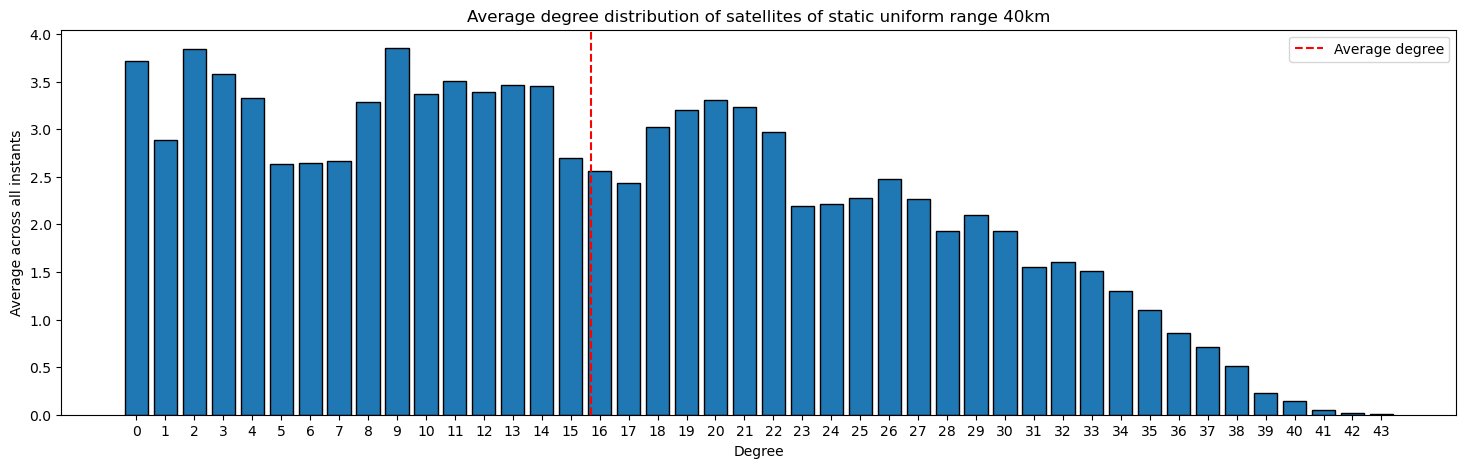

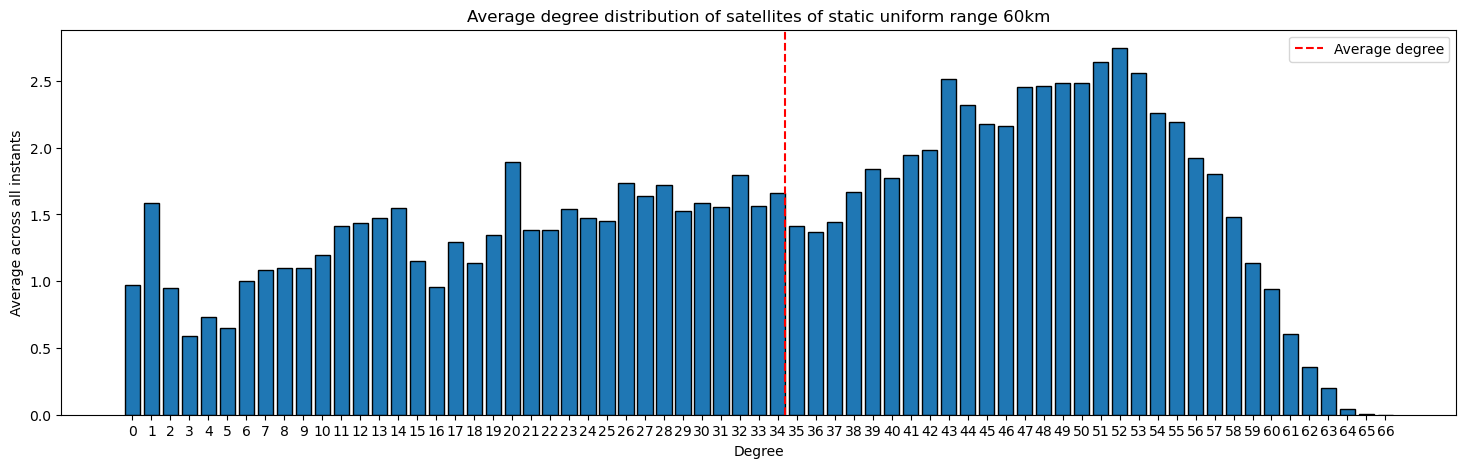

In [41]:

def average_per_degree(degree_distribution_i):
    degrees_tmp = {}
    nb_instants = len(degree_distribution_i)
    for d_distrib in degree_distribution_i:
        for key, value in d_distrib.items():
            if key in degrees_tmp:
                degrees_tmp[key] += value
            else:
                degrees_tmp[key] = value
    degrees_final = {}
    for key, value in degrees_tmp.items():
        degrees_final[str(key)] = float(value / nb_instants)
    return degrees_final

def average_overall(average_per_degree_i):
    return sum([int(key) * value for key, value in average_per_degree_i.items()]) / sum(average_per_degree_i.values())

averages = {key: average_per_degree(deg_instants) for key, deg_instants in degree_distribution_by_instant.items()}
overall_averages = {key: average_overall(avg_deg_instants) for key, avg_deg_instants in averages.items()}
#show_data(averages["20km"], "Density", "Graph density in one revolution")
for key, average_dict in averages.items():
    x = list(map(int, average_dict.keys()))
    y = list(average_dict.values())
    
    plt.figure(figsize=(18, 5))
    plt.bar(x, y, width=0.8, edgecolor="black")

    plt.axvline(x=overall_averages[key], color='r', linestyle='--', label='Average degree')
    plt.legend()  # Show the legend
    
    plt.xlabel("Degree")
    plt.ylabel("Average across all instants")
    plt.title(f"Average degree distribution of satellites of static uniform range {key}")
    
    plt.xticks(x)
    plt.show()

## Etude de la sensibilité relative, détection des noeuds sensibles

Pour étudier l'impact des pannes dans le réseau de l'essaim de nano-satellites, on doit également se poser la question de la sensibilité relative de chaque nano-satellite.

Pour déterminer quels sont les nano-satellites qui jouent un rôle plus important que les autres dans le réseau à un instant donné, il faut prendre en compte la dimension de présence, reflétant leur disponibilité, et la dimension de service, qui reflète leur contribution au fonctionnement et aux échanges au sein du réseau.

Pour la dimension de présence, comme nous l'a démontré l'étude de la valeur de Fielder, il n'est pas possible d'induire le rôle d'un nano-satellite dans le graphe dans son entièreté. On vient donc isoler le cluster principal, celui qui possède le plus de noeuds à chaque instant, en identifier les membres et compter les occurences des nano-satellites. Les plus présents sont les plus occurants.

In [ ]:
occurences = {}
# A revoir, est-ce que je ne devrais pas isoler chaque portée plutôt ou alors étudier que le 20km ?
flatten = [sat for biggest_cluster in biggest_isolated_cluster_by_instant["20km"] for sat in biggest_cluster]
for sat in flatten:
    if sat.name in occurences:
        occurences[sat.name] += 1
    else:
        occurences[sat.name] = 1

In [ ]:
sorted_occurrences = dict(sorted(occurences.items(), key=lambda x: x[1], reverse=True))
print(sorted_occurrences)

Nous allons ensuite calculer leur centralité de proximité dans ce cluster qui définit à quel point il est un élément central du graphe.

Puisque l'étude de la centralité demande de calculer des plus courts chemins, nous devons nous baser sur l'étude des instants les plus critiques.